In [4]:
!pip install keras


In [6]:
import os
import sys

# Force Google Protobuf to use pure Python instead of broken C++ modules
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# Manually register missing internal attributes to prevent Keras from crashing
import google.protobuf.internal.api_implementation as api_impl
if not hasattr(api_impl, '_c_module'):
    api_impl._c_module = None

In [7]:
!pip install tensorflow


In [8]:
%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install "protobuf<4.21.0" --force-reinstall

  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from keras.utils import to_categorical
from keras.utils import load_img
from keras.models import Sequential
from keras.layers import Dense,Conv2D, Dropout, Flatten, MaxPooling2D, Input
import os
import pandas as pd
import numpy as np

# import os
# import pandas as pd
# import numpy as np

# # Replace the broken load_img with a direct import from Keras's legacy system
# from keras.src.legacy.utils.image_utils import load_img

# # Custom manual alternative for 'to_categorical' using NumPy
# def manual_to_categorical(y, num_classes=None):
#     y = np.array(y, dtype='int')
#     input_shape = y.shape
#     if input_shape and input_shape[-1] == 1 and len(input_shape) > 1:
#         input_shape = tuple(input_shape[:-1])
#     y = y.ravel()
#     if not num_classes:
#         num_classes = np.max(y) + 1
#     n = y.shape[0]
#     categorical = np.zeros((n, num_classes))
#     categorical[np.arange(n), y] = 1
#     output_shape = input_shape + (num_classes,)
#     return np.reshape(categorical, output_shape)

# # Create mock objects so your down-stream code cells don't throw errors
# import sys
# from types import ModuleType
# if 'keras.utils' not in sys.modules:
#     utils_module = ModuleType('keras.utils')
#     utils_module.to_categorical = manual_to_categorical
#     utils_module.load_img = load_img
#     sys.modules['keras.utils'] = utils_module

In [11]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'

In [12]:
def createdataframe(dir):
    images_paths = []
    labels = []
    for label in os.listdir(dir):
        for imageName in os.listdir(os.path.join(dir, label)):
            images_paths.append(os.path.join(dir,label, imageName))
            labels.append(label)
        print(label, "completed")
    return images_paths,labels

In [13]:
train = pd.DataFrame()
train['image'],train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [14]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [15]:
test_images, test_labels = createdataframe(TEST_DIR)
test = pd.DataFrame({
    'image': test_images,
    'label': test_labels
})

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [16]:
print(test)
print(test['image'])

                              image     label
0       images/test\angry\10052.jpg     angry
1       images/test\angry\10065.jpg     angry
2       images/test\angry\10079.jpg     angry
3       images/test\angry\10095.jpg     angry
4       images/test\angry\10121.jpg     angry
...                             ...       ...
7061  images/test\surprise\9806.jpg  surprise
7062  images/test\surprise\9830.jpg  surprise
7063  images/test\surprise\9853.jpg  surprise
7064  images/test\surprise\9878.jpg  surprise
7065   images/test\surprise\993.jpg  surprise

[7066 rows x 2 columns]
0         images/test\angry\10052.jpg
1         images/test\angry\10065.jpg
2         images/test\angry\10079.jpg
3         images/test\angry\10095.jpg
4         images/test\angry\10121.jpg
                    ...              
7061    images/test\surprise\9806.jpg
7062    images/test\surprise\9830.jpg
7063    images/test\surprise\9853.jpg
7064    images/test\surprise\9878.jpg
7065     images/test\surprise\993.jpg
Name:

In [13]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from tqdm import tqdm

In [18]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image,color_mode='grayscale')
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48,48,1)
    return features

In [16]:
%pip install pillow
%pip install PIL

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
train_features = extract_features(train['image'])

  0%|          | 0/28821 [00:00<?, ?it/s]

100%|██████████| 28821/28821 [06:19<00:00, 75.92it/s]


In [20]:
test_features = extract_features(test['image'])

100%|██████████| 7066/7066 [01:35<00:00, 73.70it/s]


In [21]:
x_train = train_features/255.0
x_test = test_features/255.0

In [20]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached narwhals-2.25.0-py3-none-any.whl (467 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()
le.fit(train['label'])

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](7,)","['angry','disgust','fear',...,'neutral','sad','surprise']"


In [24]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [25]:
y_train = to_categorical(y_train,num_classes=7)
y_test = to_categorical(y_test,num_classes=7)

In [26]:
model = Sequential()

# convolutional Layers

model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add (MaxPooling2D(pool_size=(2,2)))

model.add (Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2))) 
model.add (Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu')) 
model.add(MaxPooling2D(pool_size=(2,2)))

model.add (Dropout(0.4))

model.add(Flatten())

# fully connected layers

model.add(Dense(512, activation='relu'))

model.add (Dropout(0.4))

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.3))

# output Layer

model.add(Dense(7, activation='softmax'))

c:\Users\Sanjay A\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
%pip install tensorflow==2.10

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow==2.10 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.10

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [29]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    x = x_train,
    y = y_train,
    batch_size=128,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]

)

Epoch 1/100
  6/226 ━━━━━━━━━━━━━━━━━━━━ 2:23 652ms/step - accuracy: 0.2142 - loss: 1.9093

KeyboardInterrupt: 

In [52]:
model_json = model.to_json()
with open("emotiondetector.json", "w") as json_file:
    json_file.write(model_json)
model.save("emotiondetector.keras")

In [29]:
from keras.models import model_from_json

In [30]:
json_file = open('emotiondetector.json', 'r')
model_json = json_file.read()
json_file.close()
model = model_from_json(model_json)
model.load_weights('emotiondetector.keras')

c:\Users\Sanjay A\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(store)


In [31]:
label = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

In [32]:
def ef(image):
    img = load_img(image, color_mode='grayscale')
    features = np.array(img)
    features = features.reshape(1,48,48,1)
    return features

In [35]:
image = 'images/test/fear/21.jpg'
img = ef(image)
# print('original image is angry')

print('image shape:', img.shape)

pred = model.predict(img)
print(pred)
pred_label = label[pred.argmax()]
print('predicted label is', pred_label)

image shape: (1, 48, 48, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0. 0. 1. 0. 0. 0. 0.]]
predicted label is Fear


In [39]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp311-cp311-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp311-cp311-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is fear
(1, 48, 48, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[7.88586731e-12 4.57703941e-16 9.99999523e-01 6.34854877e-11
  1.22655865e-29 2.12553897e-20 4.70402199e-07]]
predicted label is Fear


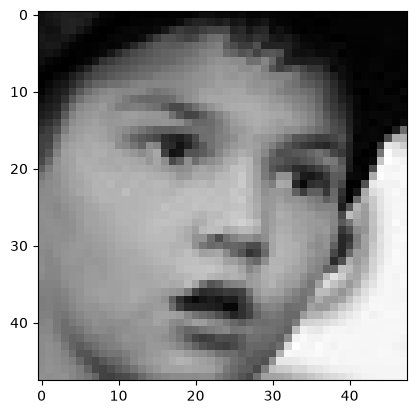

In [41]:
image = 'images/test/fear/101.jpg'
img = ef(image)
print('original image is fear')
print(img.shape)
pred = model.predict(img)
print(pred)
pred_label = label[pred.argmax()]
print('predicted label is', pred_label)
plt.imshow(img.reshape(48,48), cmap='gray')

original image is fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
predicted label is Fear


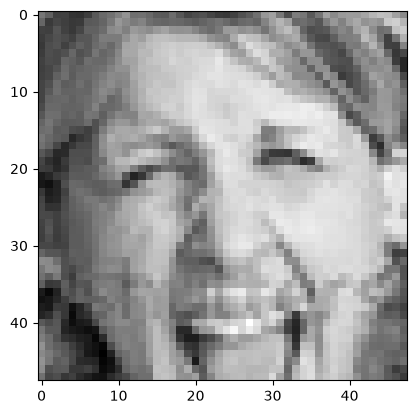

In [42]:
image = 'images/test/fear/270.jpg'
print('original image is fear')
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print('predicted label is', pred_label)
plt.imshow(img.reshape(48,48), cmap='gray')

In [43]:
import numpy as np
print(np.version)

<module 'numpy.version' from 'c:\\Users\\Sanjay A\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\numpy\\version.py'>
